In [1]:
# T05_01.py
import pandas as pd
import numpy as np

# 실습용 데이터프레임 생성
df = pd.DataFrame({
  'order_time': ['2025-01-15 10:30:00',
  '2025-03-22 19:15:30',
  '2026-07-07 02:05:55']
}) # ①

# 'order_time' 컬럼을 datetime 타입으로 변환
df['order_time'] = pd.to_datetime(df['order_time']) # ②
print(df.info()) # ③

# .dt 접근자를 사용하여 모든 시간 단위 추출
df['year'] = df['order_time'].dt.year
df['month'] = df['order_time'].dt.month
df['day'] = df['order_time'].dt.day
df['hour'] = df['order_time'].dt.hour
df['minute'] = df['order_time'].dt.minute
df['second'] = df['order_time'].dt.second
df['weekday'] = df['order_time'].dt.weekday # ④
df['day_name'] = df['order_time'].dt.day_name() # ⑤
df['quarter'] = df['order_time'].dt.quarter # ⑥
df['weekofyear'] = df['order_time'].dt.isocalendar().week # ⑦

print(df) # ⑧

df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0) # ⑨
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int) # ⑩

print(df[['order_time', 'day_name', 'is_weekend']]) # ⑪

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_time  3 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 156.0 bytes
None
           order_time  year  month  day  hour  minute  second  weekday  \
0 2025-01-15 10:30:00  2025      1   15    10      30       0        2   
1 2025-03-22 19:15:30  2025      3   22    19      15      30        5   
2 2026-07-07 02:05:55  2026      7    7     2       5      55        1   

    day_name  quarter  weekofyear  
0  Wednesday        1           3  
1   Saturday        1          12  
2    Tuesday        3          28  
           order_time   day_name  is_weekend
0 2025-01-15 10:30:00  Wednesday           0
1 2025-03-22 19:15:30   Saturday           1
2 2026-07-07 02:05:55    Tuesday           0


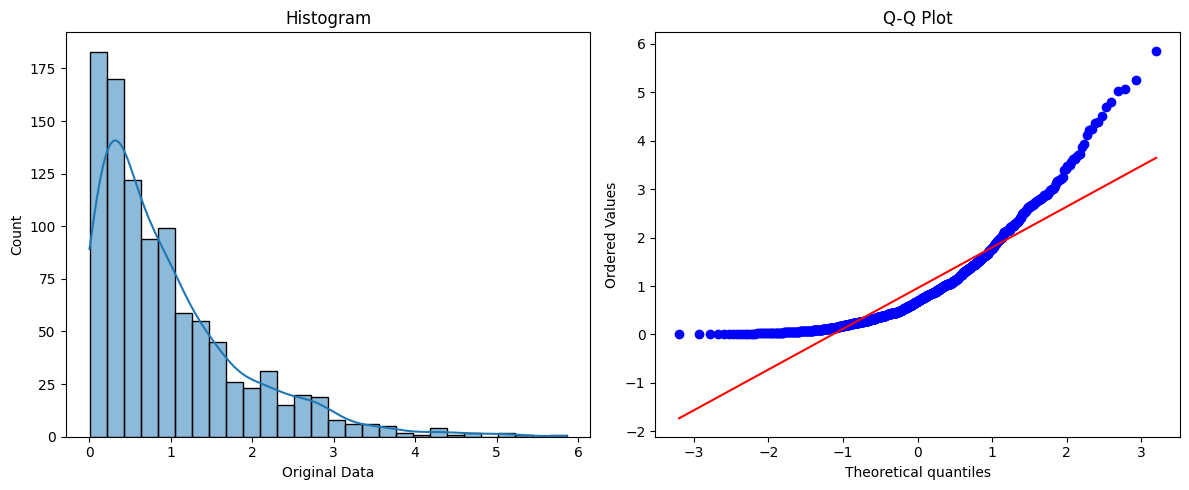

왜도(skewness): 1.6359456241092585


In [2]:
# T05_02.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 왜도가 높은 데이터 생성(지수 분포)
data = np.random.exponential(size=1000) # ①
data = pd.Series(data, name="Original Data") # ②

# 시각화를 통해 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # ③
sns.histplot(data, kde=True, ax=axes[0]) # ④
stats.probplot(data, plot=axes[1]) # ⑤
axes[0].set_title("Histogram") # ⑥
axes[1].set_title("Q-Q Plot") # ⑦
plt.tight_layout() # ⑧
plt.show()

# 왜도 계산
skewness = stats.skew(data)
print(f"왜도(skewness): {skewness}") # ⑨

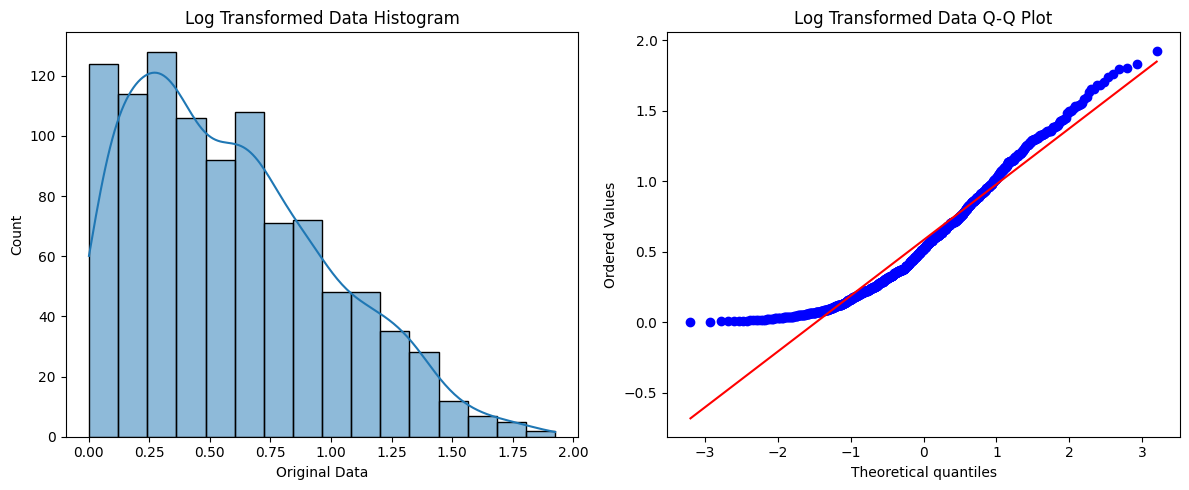

In [3]:
# T05_03.py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 로그 변환
data_log = np.log1p(data) # ①

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # ②

sns.histplot(data_log, kde=True, ax=axes[0]) # ③
axes[0].set_title("Log Transformed Data Histogram") # ④

stats.probplot(data_log, plot=axes[1]) # ⑤
axes[1].set_title("Log Transformed Data Q-Q Plot") # ⑥

plt.tight_layout() # ⑦
plt.show()

In [4]:
# T05_04.py

import pandas as pd
# 예제 나이 데이터 생성
ages = pd.Series([2, 15, 25, 35, 45, 55, 65,
                  75, 95, 22, 28, 31, 49, 61], name="Age") # ①
# 동일한 길이로 5개 구간 나누기
age_cut = pd.cut(ages, bins=5) # ②
print(age_cut.value_counts().sort_index()) # ③

# 동일한 개수로 5개 구간 나누기
age_qcut = pd.qcut(ages, q=5, labels=False, duplicates='drop') # ④
print(age_qcut.value_counts().sort_index()) # ⑤

Age
(1.907, 20.6]    2
(20.6, 39.2]     5
(39.2, 57.8]     3
(57.8, 76.4]     3
(76.4, 95.0]     1
Name: count, dtype: int64
Age
0    3
1    3
2    2
3    3
4    3
Name: count, dtype: int64


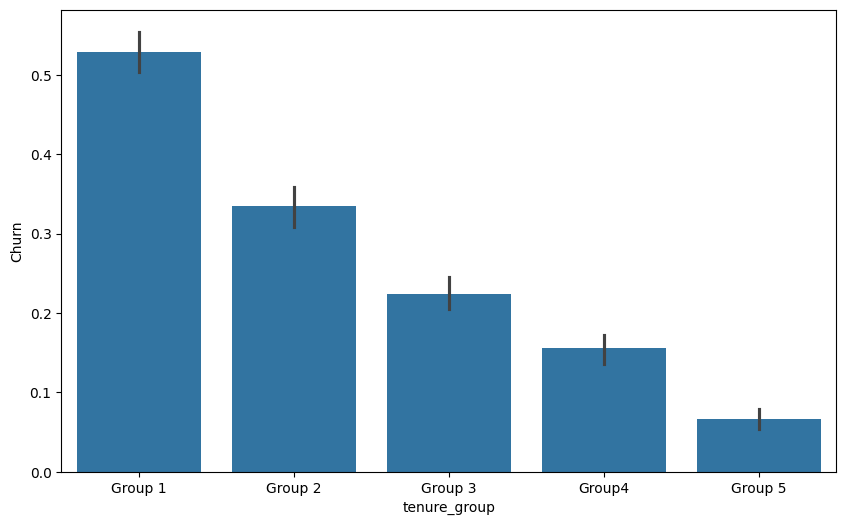

In [5]:
# T05_05.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Telco Customer Churn 데이터셋의 tenure(사용 기간)를 구간화하여 이탈률 확인
df = pd.read_csv(
  'https://raw.githubusercontent.com/' +
  'ajaedevs/python-machine-learning/' +
  'main/data/Telco-Customer-Churn.csv'
) # ①

df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0) # ②

# tenure를 5개의 그룹으로 구간화
df['tenure_group'] = pd.qcut(df['tenure'], q=5, labels=['Group 1', 'Group 2', 'Group 3', 'Group4', 'Group 5']) # ③

plt.figure(figsize=(10, 6))
sns.barplot(x='tenure_group', y='Churn', data=df) # ④
plt.show()

   pclass     sex pclass_sex
0       3    male     3_male
1       1  female   1_female
2       3  female   3_female
3       1  female   1_female
4       3    male     3_male


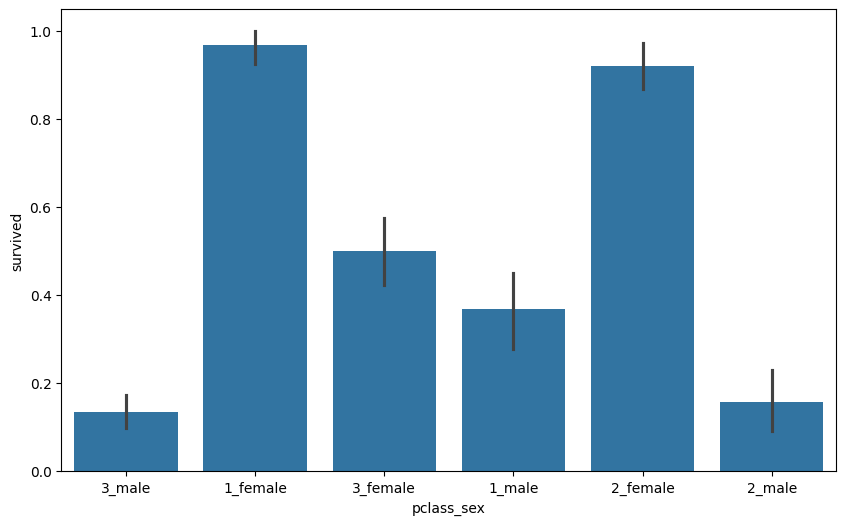

In [6]:
# T05_06.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 타이타닉 데이터 로드
titanic = sns.load_dataset('titanic') # ①

# 새로운 피처 생성
titanic['pclass_sex'] = titanic['pclass'].astype(str) + '_' + titanic['sex'] # ②
print(titanic[['pclass', 'sex', 'pclass_sex']].head()) # ③

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='pclass_sex', y='survived', data=titanic) # ④
plt.show()

In [7]:
# T05_07.py
import pandas as pd

df = pd.DataFrame({
  'category': ['A']*100 + ['B']*50 + ['C']*30 + ['D']*5 + ['E']*2
}) # ①

# 카테고리별 빈도 확인
print(df['category'].value_counts()) # ②

# 빈도수가 10개 미만인 카테고리를 찾아서 'Other'로 통합
counts = df['category'].value_counts() # ③
rare_categories = counts[counts < 10].index # ④

df['category_group'] = df['category'].replace(rare_categories, 'Other') # ⑤
print(df['category_group'].value_counts()) # ⑥

category
A    100
B     50
C     30
D      5
E      2
Name: count, dtype: int64
category_group
A        100
B         50
C         30
Other      7
Name: count, dtype: int64


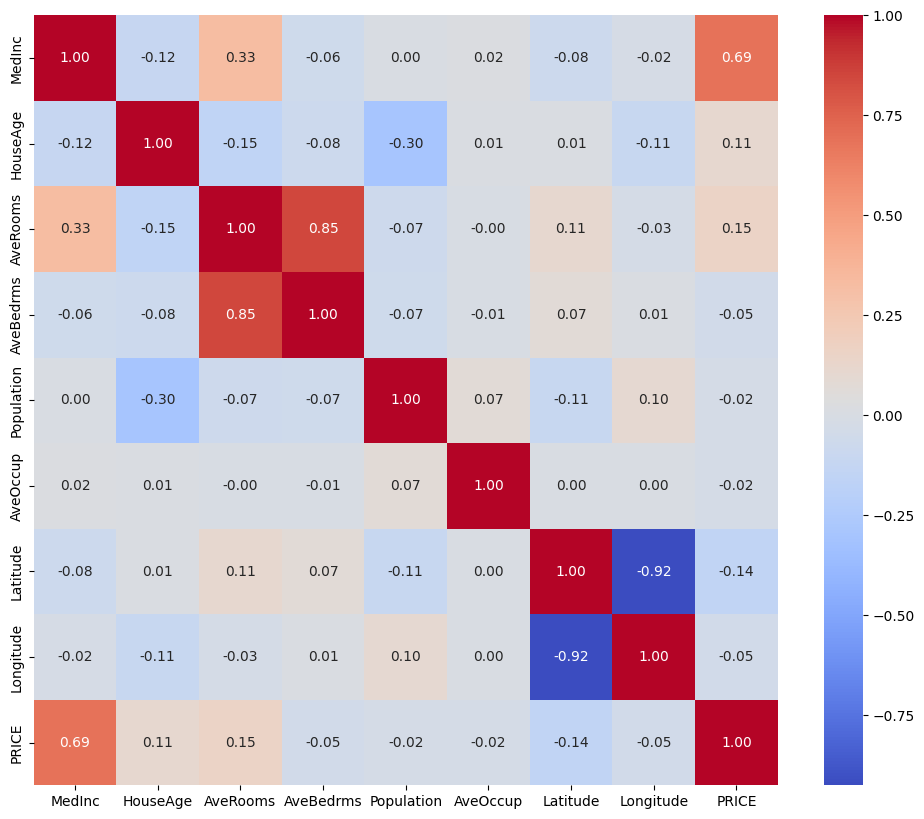

In [8]:
# T05_08.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 캘리포니아 주택 가격 데이터셋 로드
housing = fetch_california_housing() # ①
df = pd.DataFrame(housing.data, columns=housing.feature_names) # ②
df['PRICE'] = housing.target # ③

# 상관계수 행렬 계산
corr_matrix = df.corr() # ④

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm') # ⑤
plt.show()

8
[ True  True  True  True  True  True  True  True]
{'mean_test_score': array([-0.94746207, -0.8963843 , -0.63732984, -0.52439671, -0.49428763,
       -0.46774217, -0.4590391 , -0.45564536]), 'std_test_score': array([0.05618022, 0.16724046, 0.1765753 , 0.09545411, 0.08211128,
       0.08648705, 0.08339537, 0.08649439]), 'split0_test_score': array([-0.9096632 , -1.03477503, -0.62305634, -0.55876297, -0.55450475,
       -0.51307198, -0.50576356, -0.50611412]), 'split1_test_score': array([-0.90584076, -0.66108637, -0.42856048, -0.39415851, -0.37819176,
       -0.34669576, -0.34189628, -0.33391436]), 'split2_test_score': array([-1.02688225, -0.99329151, -0.86037272, -0.62026866, -0.55016638,
       -0.54345876, -0.52945747, -0.52690761]), 'n_features': array([1, 2, 3, 4, 5, 6, 7, 8])}
선택된 피처: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


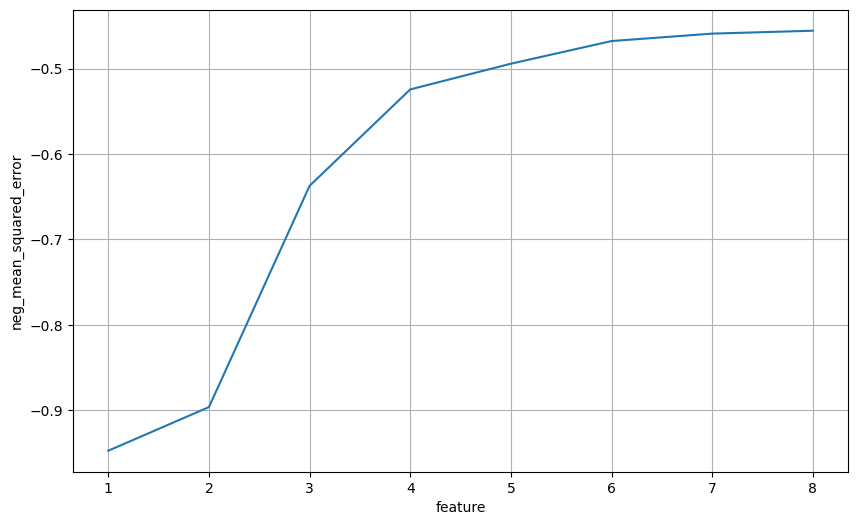

In [9]:
# T05_09.py
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor

# 데이터 준비
X = df.drop('PRICE', axis=1) # ①
y = df['PRICE'] # ②

# 모델 생성(랜덤 포레스트)
rf = RandomForestRegressor(random_state=42, n_estimators=50) # ③

# RFECV 객체 생성(cv=3, 3-폴드 교차 검증)
rfecv = RFECV(estimator=rf,
              step=1, cv=3,
              scoring='neg_mean_squared_error', n_jobs=-1) # ④
rfecv.fit(X, y) # ⑤

print(rfecv.n_features_) # ⑥
print(rfecv.support_) # ⑦
print(rfecv.cv_results_) # ⑧

print(f"선택된 피처: {X.columns[rfecv.support_].tolist()}") # ⑨

# 피처 개수에 따른 성능 변화 시각화
plt.figure(figsize=(10, 6))
plt.xlabel("feature")
plt.ylabel("neg_mean_squared_error")
plt.plot(rfecv.cv_results_['n_features'],
         rfecv.cv_results_['mean_test_score']) # ⑩
plt.grid()
plt.show()

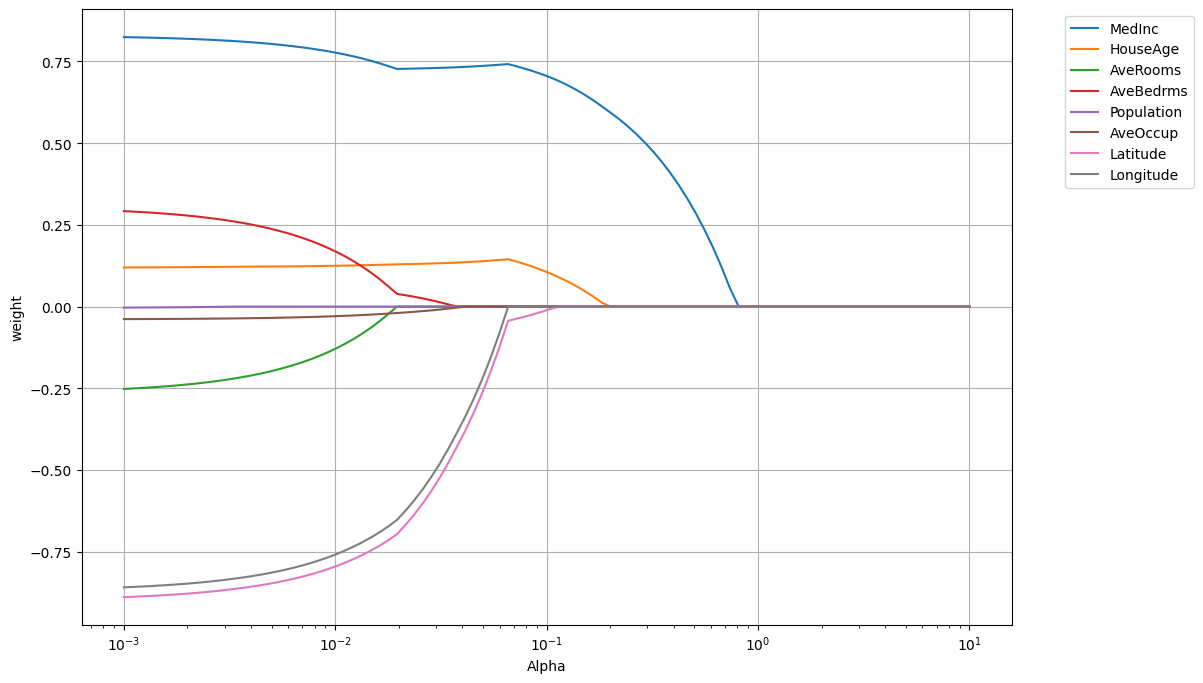

In [10]:
# T05_10.py
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# 데이터 스케일링(Lasso는 스케일에 민감함)
scaler = StandardScaler() # ①
X_scaled = scaler.fit_transform(X) # ②

# 다양한 alpha 값에 대한 가중치 계산
alphas = np.logspace(-3, 1, 100) # ③
coefs = [] # ④
for a in alphas:
  lasso = Lasso(alpha=a, random_state=42) # ⑤
  lasso.fit(X_scaled, y) # ⑥
  coefs.append(lasso.coef_) # ⑦

# 시각화
plt.figure(figsize=(12, 8))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('weight')
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc='upper left') # ⑧
plt.grid()
plt.show()

In [11]:
# T05_11.py
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import load_breast_cancer

# 실습용 유방암 데이터셋 로드
cancer = load_breast_cancer() # ①
X_train, X_test, y_train, y_test = train_test_split(
  cancer.data, cancer.target, test_size=0.2, random_state=42
) # ②

# 탐색할 초매개변수 그리드 정의
param_grid = {
  'n_estimators': [50, 100, 200], # ③
  'max_depth': [3, 5, 7], # ④
  'min_samples_leaf': [1, 3, 5] # ⑤
}

# 기본 모델 생성
rf = RandomForestClassifier(random_state=42) # ⑥

# GridSearchCV 객체 생성
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5,
scoring='accuracy', n_jobs=-1, verbose=1) # ⑦

# 그리드 서치 수행(총 27개 조합 * 5-Fold CV = 135번의 모델 학습이 수행됨)
grid_search.fit(X_train, y_train) # ⑧

# 결과 확인
print(f"최적의 초매개변수: {grid_search.best_params_}") # ⑨
print(f"최고 교차 검증 정확도: {grid_search.best_score_:.4f}") # ⑩
cv_results_df = pd.DataFrame(grid_search.cv_results_) # ⑪
print(cv_results_df.sort_values(by='rank_test_score').head()) # ⑫

Fitting 5 folds for each of 27 candidates, totalling 135 fits
최적의 초매개변수: {'max_depth': 7, 'min_samples_leaf': 1, 'n_estimators': 200}
최고 교차 검증 정확도: 0.9626
    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
20       1.105646      0.328296         0.040370        0.017319   
10       0.546406      0.132158         0.017459        0.006431   
18       0.201720      0.019586         0.010422        0.004434   
11       0.756407      0.022888         0.030322        0.006355   
19       0.690488      0.136460         0.022053        0.007233   

    param_max_depth  param_min_samples_leaf  param_n_estimators  \
20                7                       1                 200   
10                5                       1                 100   
18                7                       1                  50   
11                5                       1                 200   
19                7                       1                 100   

                                 

In [12]:
# T05_12.py
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 탐색할 초매개변수 분포 정의
param_dist = {
  'n_estimators': randint(50, 250), # ①
  'max_depth': randint(3, 15), # ②
  'min_samples_leaf': randint(1, 10) # ③
}

# RandomizedSearchCV 객체 생성
random_search = RandomizedSearchCV(estimator=rf,
                                   param_distributions=param_dist,
                                   n_iter=50, cv=5, scoring='accuracy',
                                   random_state=42,
                                   n_jobs=-1, verbose=1) # ④
random_search.fit(X_train, y_train) # ⑤

# 결과 확인
print(f"최적의 초매개변수: {random_search.best_params_}") # ⑥
print(f"최고 교차 검증 정확도: {random_search.best_score_:.4f}") # ⑦

Fitting 5 folds for each of 50 candidates, totalling 250 fits
최적의 초매개변수: {'max_depth': 6, 'min_samples_leaf': 2, 'n_estimators': 153}
최고 교차 검증 정확도: 0.9604


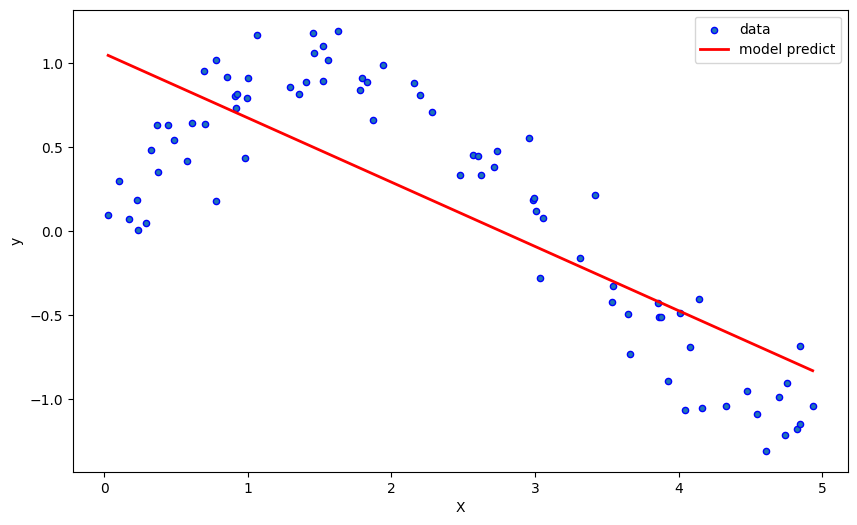

In [13]:
# T05_13.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 비선형 관계를 가진 데이터 생성
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0) # ①
y = np.sin(X).ravel() + np.random.randn(80) * 0.2 # ②

# 1차원 선형 회귀 모델(단순한 모델) 학습
model_underfit = LinearRegression() # ③
model_underfit.fit(X, y) # ④
y_pred_underfit = model_underfit.predict(X) # ⑤

# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(X, y, edgecolor='b', s=20, label="data")
plt.plot(X, y_pred_underfit, color='red', linewidth=2, label="model predict")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

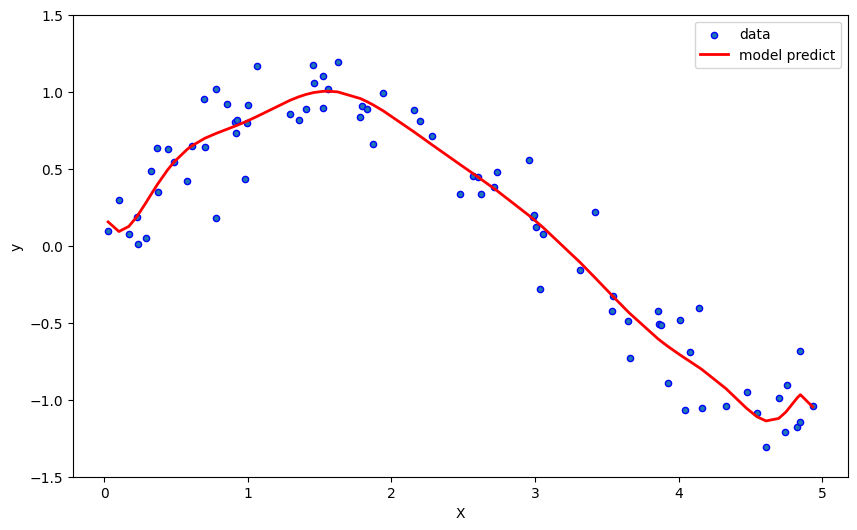

In [14]:
# T05_14.py
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 15차 다항 회귀 모델 학습
model_overfit = make_pipeline(PolynomialFeatures(degree=15),
LinearRegression()) # ①
model_overfit.fit(X, y) # ②
y_pred_overfit = model_overfit.predict(X) # ③

# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(X, y, edgecolor='b', s=20, label="data")
plt.plot(X, y_pred_overfit, color='red', linewidth=2, label="model predict")
plt.xlabel("X")
plt.ylabel("y")
plt.ylim((-1.5, 1.5)) # ④
plt.legend()
plt.show()

In [15]:
# T05_15.py
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score

# 붓꽃(Iris) 데이터셋 로드
iris = load_iris() # ①
X = iris.data # ②
y = iris.target # ③

# Decision Tree 모델 생성
dt_clf = DecisionTreeClassifier(random_state=42) # ④

# cross_val_score는 위에서 수동으로 구현한 모든 과정을 내부적으로 수행한다.
scores = cross_val_score(dt_clf, X, y, scoring='accuracy', cv=5) # ⑤

print(f"각 폴드별 정확도: {scores}") # ⑥
print(f"평균 정확도: {scores.mean():.4f}") # ⑦
print(f"정확도 표준편차: {scores.std():.4f}") # ⑧

각 폴드별 정확도: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
평균 정확도: 0.9533
정확도 표준편차: 0.0340


In [16]:
# T05_16.py
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np

# 데이터 로드
X, y = load_breast_cancer(return_X_y=True) # ①
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42
) # ②

# 단일 분할 - 단순 모델
dt_simple = DecisionTreeClassifier(max_depth=2, random_state=42) # ③
dt_simple.fit(X_train, y_train) # ④
train_simple = dt_simple.score(X_train, y_train) # ⑤
test_simple = dt_simple.score(X_test, y_test) # ⑥
print(f"단순 모델 - train: {train_simple:.4f}, test: {test_simple:.4f}") # ⑦

# 단일 분할 - 복잡 모델
dt_complex = DecisionTreeClassifier(max_depth=10, random_state=42) # ⑧
dt_complex.fit(X_train, y_train)
train_complex = dt_complex.score(X_train, y_train)
test_complex = dt_complex.score(X_test, y_test)
print(f"복잡 모델 - train: {train_complex:.4f}, test: {test_complex:.4f}")

# 단순 모델 CV 평가
scores_simple = cross_val_score(dt_simple,
                                X, y, cv=10, scoring='accuracy') # ⑨
print(f"단순 모델 CV 평균: {scores_simple.mean():.4f}") # ⑩

# 복잡 모델 CV 평가
scores_complex = cross_val_score(dt_complex,
                                 X, y, cv=10, scoring='accuracy') # ⑪
print(f"복잡 모델 CV 평균: {scores_complex.mean():.4f}") # ⑫

단순 모델 - train: 0.9422, test: 0.9298
복잡 모델 - train: 1.0000, test: 0.9415
단순 모델 CV 평균: 0.9210
복잡 모델 CV 평균: 0.9280


In [17]:
# T05_17.py
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 데이터 로드 및 분할
iris = load_iris() # ①
X_train, X_test, y_train, y_test = train_test_split(
  iris.data, iris.target, test_size=0.2, random_state=42
) # ②

# 파이프라인 정의(리스트 안에 (이름, 객체) 형태의 튜플로 전달)
pipe = Pipeline([
  ('scaler', StandardScaler()),
  ('classifier', LogisticRegression(random_state=42))
]) # ③

# 파이프라인 학습
pipe.fit(X_train, y_train) # ④

# 예측 및 평가(예측 시에도 X_test는 자동으로 scaler의 transform)
pred_pipe = pipe.predict(X_test) # ⑤
accuracy_pipe = accuracy_score(y_test, pred_pipe) # ⑥

print(f"파이프라인을 이용한 최종 모델 정확도: {accuracy_pipe:.4f}") # ⑦

파이프라인을 이용한 최종 모델 정확도: 1.0000


In [18]:
# T05_18.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 데이터 로드 및 기본 전처리
df = pd.read_csv(
  'https://raw.githubusercontent.com/' +
  'ajaedevs/python-machine-learning/' +
  'main/data/titanic.csv'
) # ①

# 불필요한 컬럼 및 타겟 변수와 관련 없는 행 제거
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1) # ②
df.dropna(subset=['Survived'], inplace=True) # ③
X = df.drop('Survived', axis=1) # ④
y = df['Survived'] # ⑤
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # ⑥

# 수치형 피처와 범주형 피처 이름 목록 정의
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare'] # ⑦
categorical_features = ['Pclass', 'Sex', 'Embarked'] # ⑧

# 각 피처 타입별 전처리 파이프라인 정의
numeric_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='median')),
  ('scaler', StandardScaler())
]) # ⑨

# 범주형 데이터 전처리
categorical_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) # ⑩

# ColumnTransformer로 두 전처리 파이프라인 통합
preprocessor = ColumnTransformer(
  transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
  ]) # ⑪

# 최종 파이프라인
final_pipeline = Pipeline(steps=[
  ('preprocessor', preprocessor),
  ('classifier', RandomForestClassifier(random_state=42))
]) # ⑫

# 최종 파이프라인 학습 및 평가
final_pipeline.fit(X_train, y_train) # ⑬
pred = final_pipeline.predict(X_test) # ⑭
accuracy = accuracy_score(y_test, pred) # ⑮
print(f"ColumnTransformer - 모델 정확도: {accuracy:.4f}") # ⑯

ColumnTransformer - 모델 정확도: 0.8156


--- 데이터셋 상위 5개 행 ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies

/tmp/ipykernel_9513/3978866485.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True) # ⑥


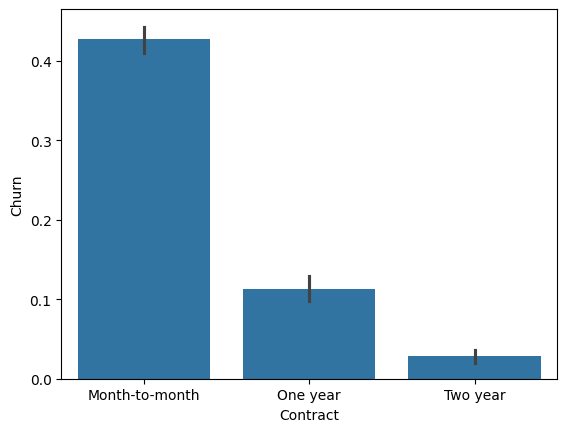

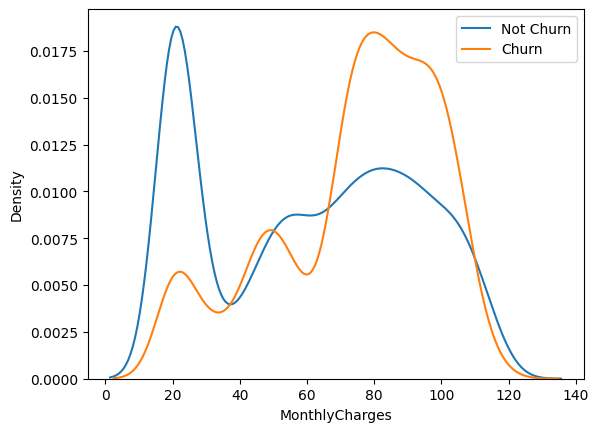

In [19]:
# Q05_01.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv(
 'https://raw.githubusercontent.com/' +
 'ajaedevs/python-machine-learning/' +
 'main/data/Telco-Customer-Churn.csv'
) # ①

# 데이터의 처음 5개 행 확인
print("--- 데이터셋 상위 5개 행 ---")
print(df.head()) # ②

# 데이터 기본 정보 확인
print("\n--- 데이터 기본 정보 (info) ---")
df.info() # ③

# TotalCharges를 숫자로 변환, 오류 발생 시 결측치로 처리
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # ④

# 결측치 확인
print(f"\nTotalCharges의 결측치 개수: {df['TotalCharges'].isnull().sum()}") # ⑤

# TotalCharges의 결측치는 tenure가 0인 신규 고객이므로 0으로 채움
df['TotalCharges'].fillna(0, inplace=True) # ⑥

# Churn 컬럼을 0과 1로 변환
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0) # ⑦

# 계약 기간(Contract)에 따른 이탈률
sns.barplot(x='Contract', y='Churn', data=df) # ⑧
plt.show()

# 월 요금(MonthlyCharges) 분포에 따른 이탈률
sns.kdeplot(df[df['Churn']==0]['MonthlyCharges'], label='Not Churn') # ⑨
sns.kdeplot(df[df['Churn']==1]['MonthlyCharges'], label='Churn') # ⑩
plt.legend()
plt.show()

In [20]:
# Q05_02.py
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 불필요한 customerID 제거
df_base = df.drop('customerID', axis=1) # ①

# 피처와 타겟 분리
X = df_base.drop('Churn', axis=1) # ②
y = df_base['Churn'] # ③

# 수치형, 범주형 피처 구분
numeric_features = X.select_dtypes(include=np.number).columns.tolist() # ④
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist() # ⑤

# 간단한 전처리 파이프라인
preprocessor = ColumnTransformer(
  transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
  ]) # ⑥

# 모델과 파이프라인 연결
baseline_model = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier',
                                  LogisticRegression(random_state=42))]) # ⑦

# 교차 검증으로 베이스라인 성능 측정
baseline_scores = cross_val_score(baseline_model, X, y, cv=5, scoring='accuracy') # ⑧

print("--- 베이스라인 모델 성능 ---")
print(f"5-Fold 교차 검증 평균 정확도: {np.mean(baseline_scores):.4f}") # ⑨

--- 베이스라인 모델 성능 ---
5-Fold 교차 검증 평균 정확도: 0.8043


In [21]:
# Q05_03.py
# 피처 엔지니어링: tenure(서비스 사용 기간)를 그룹으로 묶기
df_featured = df.copy() # ①
df_featured['tenure_group'] = pd.cut(df_featured['tenure'], bins=5, labels=[1,2,3,4,5]) # ②

# 피처와 타겟 분리
X_feat = df_featured.drop(['Churn', 'customerID', 'tenure'], axis=1) # ③
y_feat = df_featured['Churn'] # ④

# 수치형, 범주형 피처 다시 정의
numeric_features = X_feat.select_dtypes(include=np.number).columns.tolist() # ⑤
categorical_features = X_feat.select_dtypes(exclude=np.number).columns.tolist() # ⑥

# 전처리 파이프라인은 동일하게 사용
preprocessor_feat = ColumnTransformer(
  transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
  ]) # ⑦

In [22]:
# Q05_04.py
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 전처리기와 XGBoost 모델을 파이프라인으로 연결
pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor_feat),
                               ('classifier', XGBClassifier(random_state=42,
                                                            eval_metric='logloss'))])

# 튜닝할 초매개변수 그리드 정의
param_grid = {
  'classifier__n_estimators': [100, 200],
  'classifier__max_depth': [3, 5],
  'classifier__learning_rate': [0.05, 0.1],
  'classifier__colsample_bytree': [0.8, 1.0]
} # ①

# GridSearchCV 객체 생성
grid_search = GridSearchCV(pipeline_xgb, param_grid, cv=3, scoring='accuracy', n_jobs=-1) # ②

# 튜닝 수행
grid_search.fit(X_feat, y_feat) # ③
print("--- 초매개변수 튜닝 결과 ---")
print(f"최적의 초매개변수: {grid_search.best_params_}") # ④
print(f"최고 교차 검증 점수: {grid_search.best_score_:.4f}") # ⑤

# --- 성능 비교 요약 ---
print("\n--- [최종 성능 비교] ---")
print(f"베이스라인 모델 (Logistic): {np.mean(baseline_scores):.4f}") # ⑥
print(f"최종 튜닝 완료 모델 (XGBoost): {grid_search.best_score_:.4f}") # ⑦
print(f"최종 성능 향상: {grid_search.best_score_ - np.mean(baseline_scores):.4f}") # ⑧

--- 초매개변수 튜닝 결과 ---
최적의 초매개변수: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
최고 교차 검증 점수: 0.8059

--- [최종 성능 비교] ---
베이스라인 모델 (Logistic): 0.8043
최종 튜닝 완료 모델 (XGBoost): 0.8059
최종 성능 향상: 0.0016
